In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "pkdarabi/bone-break-classification-image-dataset"
)

print("Path to dataset files:", path)

100%|██████████| 28.4M/28.4M [00:00<00:00, 182MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pkdarabi/bone-break-classification-image-dataset/versions/4


In [ ]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level

    print(indent + os.path.basename(root) + '/')

    if level < 2:
        for file in files[:5]:
            print(indent + '  ' + file)

4/
  README.dataset.txt
  Bone Break Classification/
    Bone Break Classification/
      Comminuted fracture/
        Test/
        Train/
      Oblique fracture/
        Test/
        Train/
      Hairline Fracture/
        Test/
        Train/
      Impacted fracture/
        Test/
        Train/
      Longitudinal fracture/
        Test/
        Train/
      Greenstick fracture/
        Test/
        Train/
      Fracture Dislocation/
        Test/
        Train/
      Avulsion fracture/
        Test/
        Train/
      Pathological fracture/
        Test/
        Train/
      Spiral Fracture/
        Test/
        Train/


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5

In [ ]:
for item in os.listdir(path):
    print(item)

Bone Break Classification
README.dataset.txt


In [ ]:
dataset_path = os.path.join(path, "Bone Break Classification")

In [ ]:
train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

Train: /root/.cache/kagglehub/datasets/pkdarabi/bone-break-classification-image-dataset/versions/4/Bone Break Classification/train
Validation: /root/.cache/kagglehub/datasets/pkdarabi/bone-break-classification-image-dataset/versions/4/Bone Break Classification/val
Test: /root/.cache/kagglehub/datasets/pkdarabi/bone-break-classification-image-dataset/versions/4/Bone Break Classification/test


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
import os

print("Dataset path:")
print(path)

print("\nFolders and files:")

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level

    print(indent + os.path.basename(root) + '/')

    for file in files[:5]:
        print(indent + '  ' + file)

    if level >= 3:
        dirs[:] = []

Dataset path:
/root/.cache/kagglehub/datasets/pkdarabi/bone-break-classification-image-dataset/versions/4

Folders and files:
4/
  README.dataset.txt
  Bone Break Classification/
    Bone Break Classification/
      Comminuted fracture/
      Oblique fracture/
      Hairline Fracture/
      Impacted fracture/
      Longitudinal fracture/
      Greenstick fracture/
      Fracture Dislocation/
      Avulsion fracture/
      Pathological fracture/
      Spiral Fracture/


In [ ]:
dataset_path = os.path.join(
    path,
    "Bone Break Classification",
    "Bone Break Classification"
)

print(dataset_path)

/root/.cache/kagglehub/datasets/pkdarabi/bone-break-classification-image-dataset/versions/4/Bone Break Classification/Bone Break Classification


In [ ]:
import os

classes = sorted(os.listdir(dataset_path))

print("Classes:")
for i, class_name in enumerate(classes):
    print(i, class_name)

print("\nNumber of classes:", len(classes))

Classes:
0 Avulsion fracture
1 Comminuted fracture
2 Fracture Dislocation
3 Greenstick fracture
4 Hairline Fracture
5 Impacted fracture
6 Longitudinal fracture
7 Oblique fracture
8 Pathological fracture
9 Spiral Fracture

Number of classes: 10


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 907 images belonging to 10 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 222 images belonging to 10 classes.


In [ ]:
print("Number of classes:", train_generator.num_classes)
print("Class indices:", train_generator.class_indices)

Number of classes: 10
Class indices: {'Avulsion fracture': 0, 'Comminuted fracture': 1, 'Fracture Dislocation': 2, 'Greenstick fracture': 3, 'Hairline Fracture': 4, 'Impacted fracture': 5, 'Longitudinal fracture': 6, 'Oblique fracture': 7, 'Pathological fracture': 8, 'Spiral Fracture': 9}


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

NUM_CLASSES = train_generator.num_classes

model = keras.Sequential([
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 109s 4s/step - accuracy: 0.1136 - loss: 2.3989 - val_accuracy: 0.1532 - val_loss: 2.2721
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.1907 - loss: 2.2178 - val_accuracy: 0.1532 - val_loss: 2.2499
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 109s 4s/step - accuracy: 0.2767 - loss: 2.0209 - val_accuracy: 0.1937 - val_loss: 2.3446
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 105s 4s/step - accuracy: 0.4212 - loss: 1.6252 - val_accuracy: 0.1892 - val_loss: 2.6339
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.6130 - loss: 1.1772 - val_accuracy: 0.2387 - val_loss: 3.1063


In [ ]:
model.save('/content/BoneBreak_Multiclass.h5')

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

plt.figure(figsize=(15, 24))

plot_number = 1

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    selected_images = random.sample(images, min(3, len(images)))

    for image_file in selected_images:

        image_path = os.path.join(class_path, image_file)
        image = Image.open(image_path)

        plt.subplot(10, 3, plot_number)
        plt.imshow(image, cmap='gray')
        plt.title(class_name)
        plt.axis('off')

        plot_number += 1

plt.tight_layout()
plt.show()

<Figure size 1500x2400 with 0 Axes>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving download.jpg to download (1).jpg


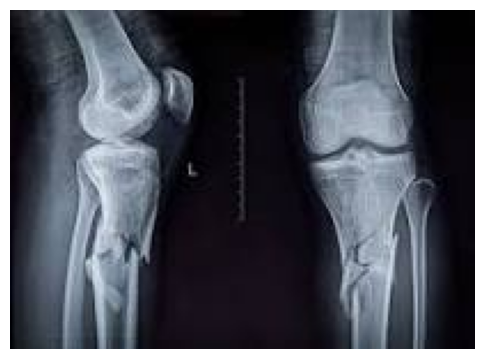

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

image_path = list(uploaded.keys())[0]

image = Image.open(image_path)

plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

image = load_img(list(uploaded.keys())[0], target_size=(224, 224))
image = img_to_array(image) / 255.0
image = np.expand_dims(image, axis=0)

In [ ]:
prediction = model.predict(image)

classes = list(train_generator.class_indices.keys())

print("Predicted class:", classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted class: Greenstick fracture
